In [2]:
%pylab
%matplotlib inline

Using matplotlib backend: <object object at 0x103d9aed0>
%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
import numpy as np
from os.path import getsize

In [3]:

def getRawImage(n):
    offset = n * self.frameSize
    self.rawSequence.seek(offset)
    st = self.rawSequence.read(self.frameSize)
    nparray = np.fromstring(st,dtype = np.uint16).reshape((self.height,self.width))
    return nparray

In [4]:
filename = 'Image_001_001.raw'

In [5]:
r = open(filename,'rb')

In [ ]:
def getImage(rawimg,n,width,height):
    frameSize = width*height*2
    offset = n*frameSize
    rawimg.seek(offset)
    st = rawimg.read(frameSize)
    nparray = np.frombuffer(st,dtype = np.uint16).reshape((height,width))
    return nparray

In [ ]:
def loadWholeStack(filename,width,height):
    r = open(filename,'rb')
    nbytes = getsize(filename)
    framesize = width*height*2
    nFrames = int(nbytes/framesize)
    stack = np.zeros((height,width,nFrames),dtype=np.uint16)
    for i in range(nFrames):
        stack[:,:,i] = getImage(r,i,width,height)
        #stack.append(getImage(r,i,width,height))
    r.close()
    return stack

In [ ]:
stack = loadWholeStack(filename,width,height)

KeyboardInterrupt: 

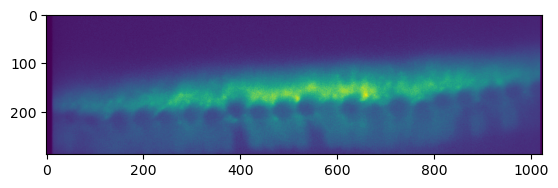

In [ ]:
imshow(stack.mean(2))

In [ ]:
lazy_imread = delayed(loadWholeStack)

In [ ]:
reader = lazy_imread(filename,width,height)

In [ ]:
stack = 0
#stack = reader.compute()

In [ ]:
dask_array = da.from_delayed(reader,shape=[width,height,nFrames],dtype=np.uint16)

In [6]:
from dask import delayed
import dask.array as da

In [26]:
def getImageFromFilename(filename,n,width,height):
    rawimg = open(filename,'rb')
    frameSize = width*height*2
    offset = n*frameSize
    rawimg.seek(offset)
    st = rawimg.read(frameSize)
    nparray = np.frombuffer(st,dtype = np.uint16).reshape((height,width))
    #r.close()
    return nparray

In [7]:
def getImage(filename,rawimg,n,width,height):
    frameSize = width*height*2
    offset = n*frameSize
    rawimg.seek(offset)
    st = rawimg.read(frameSize)
    nparray = np.frombuffer(st,dtype = np.uint16).reshape((height,width))
    return nparray

In [27]:
r = open(filename,'rb')
width=1024
height=288
nbytes = getsize(filename)
framesize = width*height*2
nFrames = int(nbytes/framesize)
r.close()

In [28]:
lazy_imread = delayed(getImageFromFilename)

In [29]:
lazy_arrays = [lazy_imread(filename,n,width,height) for n in range(nFrames)]

In [30]:
dask_array = [da.from_delayed(delayed_reader,shape=[width,height],dtype=np.uint16) for delayed_reader in lazy_arrays]

In [31]:
stack = da.stack(dask_array,axis=0)
stack.shape 

(7330, 1024, 288)

In [32]:
stack

dask.array<stack, shape=(7330, 1024, 288), dtype=uint16, chunksize=(1, 1024, 288), chunktype=numpy.ndarray>

In [33]:
from functools import partial

In [34]:
stack2 = stack.rechunk({0:1,1:1024,2:288})

In [35]:
stack2

dask.array<stack, shape=(7330, 1024, 288), dtype=uint16, chunksize=(1, 1024, 288), chunktype=numpy.ndarray>

In [4]:
import dask_image
import dask_image.ndfilters

In [37]:
stack3= dask_image.ndfilters.gaussian_filter(stack2,sigma=(2,2,2))

In [41]:
stack3.compute_chunk_sizes()

dask.array<_trim, shape=(7330, 288, 1024), dtype=uint16, chunksize=(10, 288, 1024), chunktype=numpy.ndarray>

In [49]:
stack3 = stack3.rechunk({0:1,1:288,2:1024})

In [58]:
stack3.to_zarr('test.zarr',compressor=None)

In [9]:
import napari

In [60]:
napari.view_image(stack3, contrast_limits=[0,1000], multiscale=False)

Viewer(axes=Axes(visible=False, labels=True, colored=True, dashed=False, arrows=True), camera=Camera(center=(0.0, 143.5, 511.5), zoom=0.7533203125, angles=(0.0, 0.0, 90.0), perspective=0.0, interactive=True), cursor=Cursor(position=(3665.0, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((0.0, 7330.0, 1.0), (0.0, 288.0, 1.0), (0.0, 1024.0, 1.0)), current_step=(3665, 144, 512), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'stack3' at 0x377d0bca0>], scale_bar=ScaleBar(visible=False, colored=False, color=array([1., 0., 1., 1.], dtype=float32), ticks=True, position=<Position.BOTTOM_RIGHT: 'bottom_right'>, font_size=10.0, box=False, box_color=array([0. , 0. , 0. , 0.6], dtype=float32), unit=None), text_overlay=TextOverlay(visible=False, color=array([0.5, 0.5, 0.5, 1. ], dtype=float32), font_size=10.0, position=<TextOverlayPosition.TOP_

In [48]:
import zarr

In [52]:
zarr.open('./Image_001_001.raw',mode='r',shape=(width,height,nFrames))

FSPathExistNotDir: path exists but is not a directory: %r

In [12]:
stack4 = da.from_zarr('test.zarr')

In [13]:
napari.view_image(stack4, contrast_limits=[0,1000], multiscale=False)

Viewer(axes=Axes(visible=False, labels=True, colored=True, dashed=False, arrows=True), camera=Camera(center=(0.0, 143.5, 511.5), zoom=0.7533203125, angles=(0.0, 0.0, 90.0), perspective=0.0, interactive=True), cursor=Cursor(position=(3665.0, 1.0, 0.0), scaled=True, size=1, style=<CursorStyle.STANDARD: 'standard'>), dims=Dims(ndim=3, ndisplay=2, last_used=0, range=((0.0, 7330.0, 1.0), (0.0, 288.0, 1.0), (0.0, 1024.0, 1.0)), current_step=(3665, 144, 512), order=(0, 1, 2), axis_labels=('0', '1', '2')), grid=GridCanvas(stride=1, shape=(-1, -1), enabled=False), layers=[<Image layer 'stack4' at 0x168cabcd0>], scale_bar=ScaleBar(visible=False, colored=False, color=array([1., 0., 1., 1.], dtype=float32), ticks=True, position=<Position.BOTTOM_RIGHT: 'bottom_right'>, font_size=10.0, box=False, box_color=array([0. , 0. , 0. , 0.6], dtype=float32), unit=None), text_overlay=TextOverlay(visible=False, color=array([0.5, 0.5, 0.5, 1. ], dtype=float32), font_size=10.0, position=<TextOverlayPosition.TOP_

In [14]:
napari.run()

In [17]:
stack4.shape

(7330, 288, 1024)